In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/world_happiness_ml.csv")

df_ml.head()

,Country,Year,Climate_Index,Corruption_Perception,Crime_Rate,Education_Index,Employment_Rate,Freedom,GDP_per_Capita,Generosity,Happiness_Score,Healthy_Life_Expectancy,Income_Inequality,Internet_Access,Life_Satisfaction,Mental_Health_Index,Political_Stability,Population,Public_Health_Expenditure,Public_Trust,Social_Support,Unemployment_Rate,Urbanization_Rate,Work_Life_Balance,Year_bin
0,Australia,2005,64.565333,0.517333,44.341333,0.778000,72.108667,0.372000,28886.978000,0.181333,5.430667,68.128667,41.165333,71.750667,5.685333,74.255333,0.552667,7.037067e+08,5.525333,0.512667,0.528667,11.041333,59.478667,6.286667,2005
1,Australia,2006,69.659444,0.449444,47.636111,0.736667,73.490556,0.495000,28936.431111,0.100556,6.030556,63.465000,36.857222,67.400556,6.388333,75.430000,0.516111,7.845685e+08,5.838333,0.481111,0.677222,8.176111,61.441111,5.902222,2005
2,Australia,2007,66.739091,0.487273,46.938636,0.780455,73.953636,0.529545,36317.625455,0.167273,5.600000,65.911818,38.910000,68.869545,6.788636,71.362727,0.564545,6.854900e+08,6.015000,0.530000,0.505000,9.251818,64.544545,5.937273,2005
3,Australia,2008,59.651111,0.480556,47.990556,0.696667,69.658333,0.616667,27944.319444,0.170000,5.868889,69.021111,33.376667,73.648889,6.635556,60.281667,0.658333,8.398988e+08,6.148333,0.530000,0.467778,13.337222,64.130556,5.455000,2005
4,Australia,2009,55.751905,0.549048,37.245238,0.756667,73.119048,0.574762,29764.803810,0.088571,5.182857,69.346667,47.194286,69.601905,6.563333,66.839048,0.486190,6.325921e+08,6.183810,0.436667,0.524762,11.704762,60.689524,6.234286,2005


In [2]:
# Target variable
y = df_ml["Life_Satisfaction"]

# Features
X = df_ml.drop(columns=["Life_Satisfaction", "Country", "Year_bin"])

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R2:", r2_lin)

Linear Regression Results
MAE: 0.32509163025698956
RMSE: 0.4047257387821686
R2: -0.4596992363977004


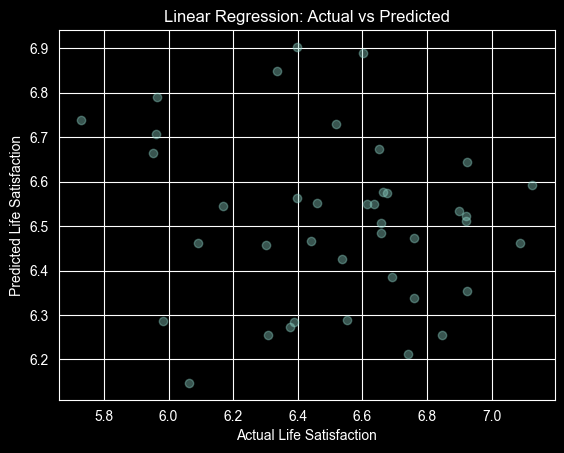

In [6]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lin, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [7]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree Regressor Results
MAE: 0.34185145459217287
RMSE: 0.4090443740672408
R2: -0.49101694625139825


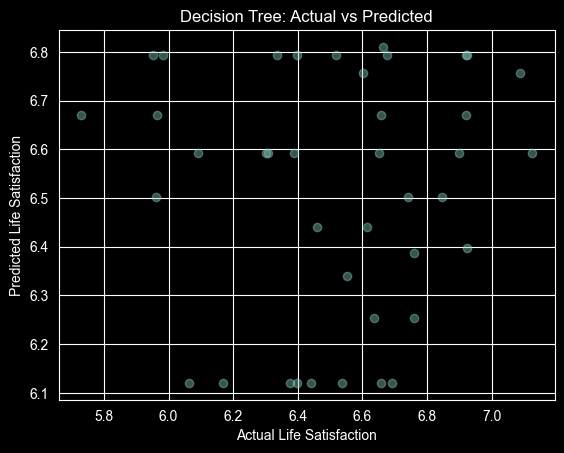

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_tree, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [10]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

tree_importance.head(15)

Income_Inequality            0.174246
Mental_Health_Index          0.159617
Unemployment_Rate            0.122123
Freedom                      0.121364
Urbanization_Rate            0.105051
Public_Health_Expenditure    0.079488
Crime_Rate                   0.076121
Happiness_Score              0.067488
Social_Support               0.061383
Employment_Rate              0.033120
Education_Index              0.000000
Corruption_Perception        0.000000
Year                         0.000000
Climate_Index                0.000000
Internet_Access              0.000000
dtype: float64

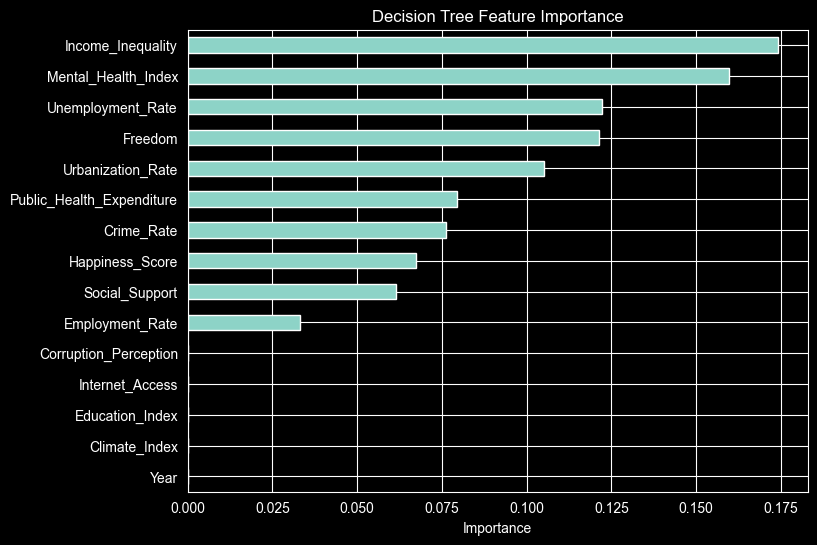

In [11]:
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Regressor Results
MAE: 0.2659379047711692
RMSE: 0.3337669957206079
R2: 0.007276023790851904


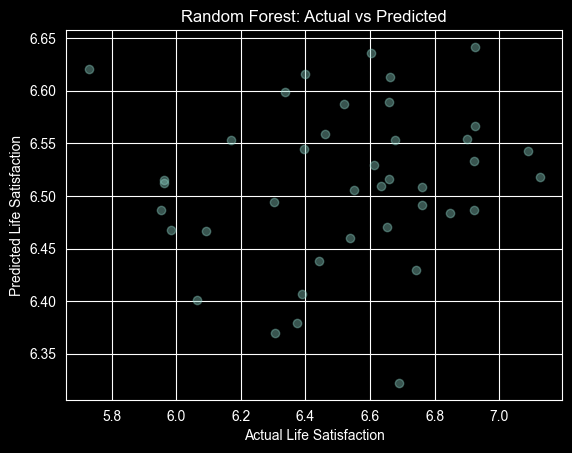

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [15]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)

Mental_Health_Index        0.087771
Corruption_Perception      0.080931
Freedom                    0.078287
GDP_per_Capita             0.050012
Climate_Index              0.046969
Income_Inequality          0.046372
Employment_Rate            0.045618
Generosity                 0.045272
Social_Support             0.044729
Population                 0.044430
Political_Stability        0.044277
Urbanization_Rate          0.042654
Public_Trust               0.040021
Work_Life_Balance          0.037518
Healthy_Life_Expectancy    0.037134
dtype: float64

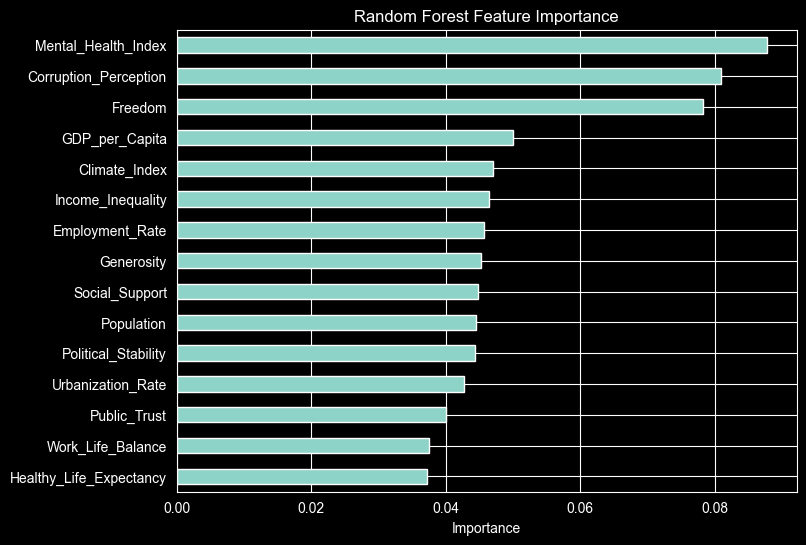

In [16]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Results
MAE: 0.29681703158126377
RMSE: 0.3695036748878689
R2: -0.21668808734710177


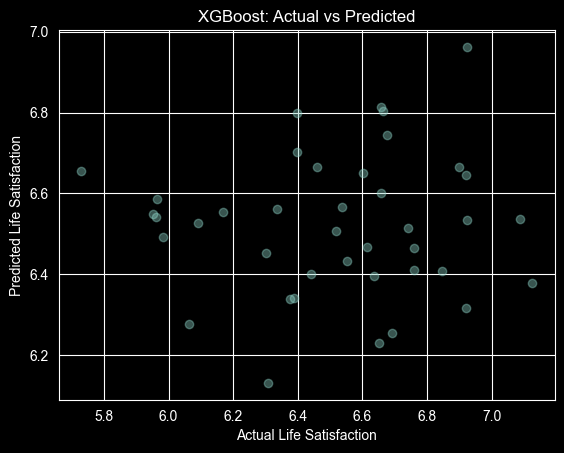

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [20]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

Mental_Health_Index          0.107060
Urbanization_Rate            0.069838
Political_Stability          0.069011
Freedom                      0.063005
Unemployment_Rate            0.058592
Social_Support               0.056237
Income_Inequality            0.050756
Employment_Rate              0.047594
Public_Health_Expenditure    0.046868
Work_Life_Balance            0.044371
Public_Trust                 0.042217
Climate_Index                0.038895
Population                   0.038571
Happiness_Score              0.037418
Corruption_Perception        0.035946
dtype: float32


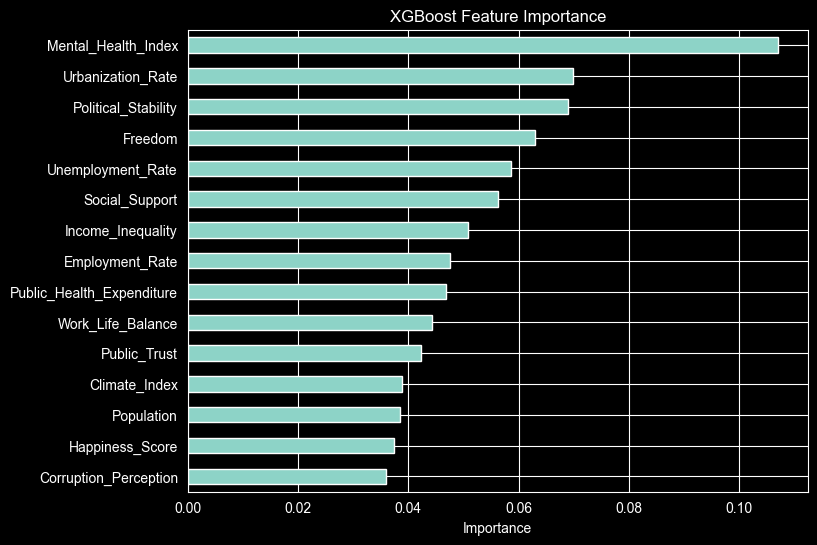

In [21]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()